In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




In [2]:
np.random.seed(42)

data = {
    'packet_count': np.random.randint(10, 1000, 200),
    'packet_size': np.random.randint(40, 1500, 200),
    'duration': np.random.randint(1, 100, 200),
    'failed_connections': np.random.randint(0, 20, 200)
}

df = pd.DataFrame(data)

df['intrusion'] = (
    (df['packet_count'] > 700) |
    (df['failed_connections'] > 12) |
    (df['packet_size'] > 1200)
).astype(int)

df.head()


,packet_count,packet_size,duration,failed_connections,intrusion
0,112,524,97,3,0
1,445,1470,63,3,1
2,870,270,85,9,1
3,280,788,32,4,0
4,116,1234,87,8,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['intrusion'].value_counts())


Dataset Shape: (200, 5)

Missing Values:
packet_count          0
packet_size           0
duration              0
failed_connections    0
intrusion             0
dtype: int64

Class Distribution:
intrusion
1    130
0     70
Name: count, dtype: int64


In [4]:
X = df[['packet_count', 'packet_size', 'duration', 'failed_connections']]
y = df['intrusion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (160, 4)
Testing Data: (40, 4)


In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")


Random Forest Model Trained Successfully!


In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")


Model Accuracy: 100.0 %


Confusion Matrix:
[[14  0]
 [ 0 26]]


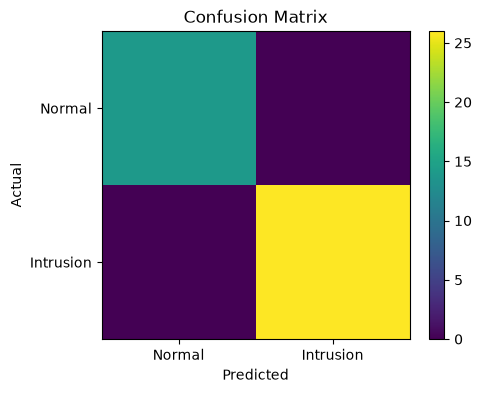

In [7]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0, 1], ["Normal", "Intrusion"])
plt.yticks([0, 1], ["Normal", "Intrusion"])

plt.show()


In [8]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Intrusion"]
))


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        14
   Intrusion       1.00      1.00      1.00        26

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [9]:
new_data = pd.DataFrame({
    'packet_count': [850, 100],
    'packet_size': [1300, 500],
    'duration': [20, 80],
    'failed_connections': [15, 2]
})

prediction = model.predict(new_data)

for i, result in enumerate(prediction):
    if result == 1:
        print(f"Sample {i+1}: Intrusion Detected")
    else:
        print(f"Sample {i+1}: Normal Traffic")



Sample 1: Intrusion Detected
Sample 2: Normal Traffic
